# 04 — ONNX Export, INT8 Quantization & Latency Benchmarking

**Project:** LWM-LoRA: Scenario-Adaptive mmWave Beam Prediction via LoRA-Tuned Foundation Models for 6G Networks  
**Author:** Nabeegh Khan | MEng ECE Candidate, University of Toronto  
**Portfolio:** [github.com/nabeegh-khan/6g-lwm-beam-prediction](https://github.com/nabeegh-khan/6g-lwm-beam-prediction)

---

## What this notebook does

1. Exports the best LWMLoRA model (r=4, Miami) to **ONNX format**
2. Applies **INT8 dynamic quantization** via ONNX Runtime
3. Benchmarks inference latency across three configurations:
   - PyTorch FP32 (GPU)
   - ONNX Runtime FP32 (CPU)
   - ONNX Runtime INT8 quantized (CPU)
4. Reports model size reduction and latency speedup
5. Validates that quantized model accuracy matches the original

## Context
Edge deployment at base stations requires low-latency inference.
Quantization reduces model size and speeds up CPU inference —
relevant for O-RAN xApp deployment where GPU is not always available.

In [1]:
%pip install -q onnx onnxruntime onnxscript wandb --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 16.8 MB/s eta 0:00:00


## Section 1 — Environment Setup

In [2]:
import os, sys, random, subprocess, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

import onnx
import onnxruntime as ort

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device:         {device}")
print(f"PyTorch:        {torch.__version__}")
print(f"ONNX:           {onnx.__version__}")
print(f"ONNX Runtime:   {ort.__version__}")

Device:         cuda
PyTorch:        2.10.0+cu128
ONNX:           1.21.0
ONNX Runtime:   1.24.4


## Section 2 — Mount Drive, Load Model & Data

In [3]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/6g-lwm-beam-prediction")
PROC_DIR   = DRIVE_ROOT / "data" / "processed"
CKPT_DIR   = DRIVE_ROOT / "checkpoints"
FIG_DIR    = DRIVE_ROOT / "figures"
ONNX_DIR   = DRIVE_ROOT / "onnx_models"
ONNX_DIR.mkdir(parents=True, exist_ok=True)

# clone LWM and rebuild model classes
LWM_DIR = "/content/LWM"
if not os.path.exists(LWM_DIR):
    subprocess.run(["git", "clone",
                    "https://huggingface.co/wi-lab/lwm-v1.1", LWM_DIR],
                   capture_output=True)
if LWM_DIR not in sys.path:
    sys.path.insert(0, LWM_DIR)

from lwm_model import lwm as LWMModel

class LoRALinear(nn.Module):
    def __init__(self, original, r, lora_alpha=32, lora_dropout=0.1):
        super().__init__()
        self.original = original
        d_in, d_out   = original.in_features, original.out_features
        self.scaling  = lora_alpha / r
        self.dropout  = nn.Dropout(lora_dropout)
        self.lora_A   = nn.Linear(d_in, r, bias=False)
        self.lora_B   = nn.Linear(r, d_out, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        for p in self.original.parameters():
            p.requires_grad = False
    def forward(self, x):
        return self.original(x) + self.scaling * self.lora_B(
            self.lora_A(self.dropout(x)))

class BeamMLP(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=256, n_beams=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//2), nn.BatchNorm1d(hidden_dim//2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, n_beams),
        )
    def forward(self, x):
        return self.net(x)

class LWMLoRA(nn.Module):
    def __init__(self, lwm_encoder, n_beams=64):
        super().__init__()
        self.encoder = lwm_encoder
        self.head    = BeamMLP(input_dim=128, hidden_dim=256,
                               n_beams=n_beams, dropout=0.3)
    def forward(self, patches):
        enc_out = self.encoder(patches)
        cls_emb = enc_out[0][:, 0, :]
        return self.head(cls_emb)

def inject_lora(model, target_suffixes, r, lora_alpha=32, lora_dropout=0.1):
    for p in model.parameters():
        p.requires_grad = False
    for name, module in list(model.named_modules()):
        if not isinstance(module, nn.Linear):
            continue
        if name.split(".")[-1] not in target_suffixes:
            continue
        parts  = name.split(".")
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)
        setattr(parent, parts[-1],
                LoRALinear(module, r=r,
                           lora_alpha=lora_alpha,
                           lora_dropout=lora_dropout))
    return model

def load_lwm_lora(ckpt_path, r=4, device="cuda"):
    """Load a saved LWMLoRA checkpoint."""
    base    = LWMModel().to(device)
    sd      = torch.load(f"{LWM_DIR}/models/model.pth", map_location=device)
    base.load_state_dict({k.replace("module.", ""): v for k, v in sd.items()})
    encoder = inject_lora(base, ["W_Q","W_K","W_V","linear"], r=r)
    model   = LWMLoRA(encoder, n_beams=64).to(device)
    model.load_state_dict(torch.load(str(ckpt_path), map_location=device))
    model.eval()
    return model

# load best model (r=4, Miami)
ckpt_path = CKPT_DIR / "lwm_lora_r4_source_miami.pt"
model     = load_lwm_lora(ckpt_path, r=4, device=device)
print(f"Model loaded from {ckpt_path.name}")

# load Miami test data for accuracy validation
saved      = torch.load(str(PROC_DIR / "city_6_miami.pt"), map_location="cpu")
patches    = saved["patches"].float()
labels     = saved["labels"].long()
test_ds    = TensorDataset(patches[:1000], labels[:1000])  # 1000 samples for benchmarking
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
print(f"Test set: {len(test_ds)} samples")

Mounted at /content/drive
Model loaded from lwm_lora_r4_source_miami.pt
Test set: 1000 samples


## Section 3 — ONNX Export

Export the full LWMLoRA model to ONNX format.
We use a fixed sequence length matching city_6_miami (seq_len=33)
since ONNX requires static or explicitly dynamic input shapes.

In [4]:
import wandb
wandb.login()

run = wandb.init(
    project="6g-lwm-beam-prediction",
    name="04_onnx_deployment",
    tags=["onnx", "quantization", "inference", "deployment"],
    config={
        "model": "LWMLoRA_r4_miami",
        "seq_len": 33,
        "patch_size": 32,
        "n_beams": 64,
        "quantization": "INT8_dynamic",
    },
    notes="ONNX export + INT8 quantization + latency benchmark"
)

print(f"W&B run: {run.name}")
print(f"W&B URL: {run.url}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nabeegh-khan (nabeegh-khan-university-of-toronto) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run: 04_onnx_deployment
W&B URL: https://wandb.ai/nabeegh-khan-university-of-toronto/6g-lwm-beam-prediction/runs/6lsjyk7i


In [5]:
# export the trained LWMLoRA model to ONNX format
ONNX_PATH   = ONNX_DIR / "lwm_lora_r4_miami.onnx"
dummy_input = torch.randn(1, 33, 32).to(device)

model.eval()
print("Exporting to ONNX (legacy API)...")
with torch.no_grad():
    torch.onnx.export(
        model,
        dummy_input,
        str(ONNX_PATH),
        export_params=True,
        opset_version=14,
        do_constant_folding=True,
        input_names=["patches"],
        output_names=["logits"],
        dynamic_axes={
            "patches": {0: "batch_size"},
            "logits":  {0: "batch_size"},
        },
        dynamo=False,       # force legacy exporter
        verbose=False
    )

onnx_model   = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)
fp32_size_mb = ONNX_PATH.stat().st_size / 1e6

print(f"ONNX export valid.")
print(f"FP32 model size: {fp32_size_mb:.2f} MB")
print(f"Saved → {ONNX_PATH}")

Exporting to ONNX (legacy API)...
ONNX export valid.
FP32 model size: 10.56 MB
Saved → /content/drive/MyDrive/6g-lwm-beam-prediction/onnx_models/lwm_lora_r4_miami.onnx


## Section 4 — INT8 Dynamic Quantization

Dynamic quantization converts weight matrices to INT8 at export time
and quantizes activations on-the-fly during inference.
No calibration dataset required — making it practical for deployment.

In [6]:
from onnxruntime.quantization import quantize_dynamic, QuantType

ONNX_Q_PATH = ONNX_DIR / "lwm_lora_r4_miami_int8.onnx"

print("Applying INT8 dynamic quantization...")
quantize_dynamic(
    model_input=str(ONNX_PATH),
    model_output=str(ONNX_Q_PATH),
    weight_type=QuantType.QInt8,
)

int8_size_mb = ONNX_Q_PATH.stat().st_size / 1e6
print(f"INT8 model size:  {int8_size_mb:.2f} MB")
print(f"FP32 model size:  {fp32_size_mb:.2f} MB")
print(f"Size reduction:   {(1 - int8_size_mb/fp32_size_mb)*100:.1f}%")
print(f"Saved → {ONNX_Q_PATH}")

Applying INT8 dynamic quantization...
INT8 model size:  3.22 MB
FP32 model size:  10.56 MB
Size reduction:   69.5%
Saved → /content/drive/MyDrive/6g-lwm-beam-prediction/onnx_models/lwm_lora_r4_miami_int8.onnx


## Section 5 — Latency Benchmarking

Compare inference latency across three configurations:
- PyTorch FP32 on GPU
- ONNX Runtime FP32 on CPU  
- ONNX Runtime INT8 on CPU

We benchmark on single-sample inference (batch=1) — the realistic
deployment scenario for real-time beam prediction at a base station.

In [7]:
N_WARMUP = 50
N_BENCH  = 500

# single sample input — batch=1 is the real-time deployment case
single_patch_gpu = torch.randn(1, 33, 32).to(device)
single_patch_cpu = single_patch_gpu.cpu().numpy()

# ---- 1. PyTorch FP32 GPU ----
print("Benchmarking PyTorch FP32 (GPU)...")
model.eval()
# warmup
for _ in range(N_WARMUP):
    with torch.no_grad():
        _ = model(single_patch_gpu)
torch.cuda.synchronize()

times_pt = []
for _ in range(N_BENCH):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(single_patch_gpu)
    torch.cuda.synchronize()
    times_pt.append((time.perf_counter() - t0) * 1000)   # ms

pt_mean  = np.mean(times_pt)
pt_std   = np.std(times_pt)
pt_p99   = np.percentile(times_pt, 99)
print(f"  Mean: {pt_mean:.3f} ms | Std: {pt_std:.3f} ms | P99: {pt_p99:.3f} ms")

# ---- 2. ONNX Runtime FP32 CPU ----
print("\nBenchmarking ONNX Runtime FP32 (CPU)...")
sess_fp32 = ort.InferenceSession(
    str(ONNX_PATH),
    providers=["CPUExecutionProvider"]
)
# warmup
for _ in range(N_WARMUP):
    _ = sess_fp32.run(None, {"patches": single_patch_cpu})

times_onnx_fp32 = []
for _ in range(N_BENCH):
    t0 = time.perf_counter()
    _ = sess_fp32.run(None, {"patches": single_patch_cpu})
    times_onnx_fp32.append((time.perf_counter() - t0) * 1000)

onnx_fp32_mean = np.mean(times_onnx_fp32)
onnx_fp32_std  = np.std(times_onnx_fp32)
onnx_fp32_p99  = np.percentile(times_onnx_fp32, 99)
print(f"  Mean: {onnx_fp32_mean:.3f} ms | Std: {onnx_fp32_std:.3f} ms | "
      f"P99: {onnx_fp32_p99:.3f} ms")

# ---- 3. ONNX Runtime INT8 CPU ----
print("\nBenchmarking ONNX Runtime INT8 (CPU)...")
sess_int8 = ort.InferenceSession(
    str(ONNX_Q_PATH),
    providers=["CPUExecutionProvider"]
)
for _ in range(N_WARMUP):
    _ = sess_int8.run(None, {"patches": single_patch_cpu})

times_onnx_int8 = []
for _ in range(N_BENCH):
    t0 = time.perf_counter()
    _ = sess_int8.run(None, {"patches": single_patch_cpu})
    times_onnx_int8.append((time.perf_counter() - t0) * 1000)

onnx_int8_mean = np.mean(times_onnx_int8)
onnx_int8_std  = np.std(times_onnx_int8)
onnx_int8_p99  = np.percentile(times_onnx_int8, 99)
print(f"  Mean: {onnx_int8_mean:.3f} ms | Std: {onnx_int8_std:.3f} ms | "
      f"P99: {onnx_int8_p99:.3f} ms")

# ---- summary ----
print(f"\n{'='*60}")
print(f"LATENCY BENCHMARK SUMMARY (batch=1, {N_BENCH} runs)")
print(f"{'='*60}")
print(f"{'Config':<28} {'Mean (ms)':>10} {'P99 (ms)':>10} {'Speedup':>10}")
print("-" * 60)
print(f"{'PyTorch FP32 (GPU)':<28} {pt_mean:>10.3f} {pt_p99:>10.3f} {'1.00x':>10}")
print(f"{'ONNX FP32 (CPU)':<28} {onnx_fp32_mean:>10.3f} {onnx_fp32_p99:>10.3f} "
      f"{pt_mean/onnx_fp32_mean:>10.2f}x")
print(f"{'ONNX INT8 (CPU)':<28} {onnx_int8_mean:>10.3f} {onnx_int8_p99:>10.3f} "
      f"{pt_mean/onnx_int8_mean:>10.2f}x")

Benchmarking PyTorch FP32 (GPU)...
  Mean: 17.049 ms | Std: 2.842 ms | P99: 28.784 ms

Benchmarking ONNX Runtime FP32 (CPU)...
  Mean: 5.051 ms | Std: 1.435 ms | P99: 8.706 ms

Benchmarking ONNX Runtime INT8 (CPU)...
  Mean: 8.526 ms | Std: 5.932 ms | P99: 33.188 ms

LATENCY BENCHMARK SUMMARY (batch=1, 500 runs)
Config                        Mean (ms)   P99 (ms)    Speedup
------------------------------------------------------------
PyTorch FP32 (GPU)               17.049     28.784      1.00x
ONNX FP32 (CPU)                   5.051      8.706       3.38x
ONNX INT8 (CPU)                   8.526     33.188       2.00x


In [8]:
def eval_pytorch(model, loader, device):
    model.eval()
    correct_top1 = correct_top3 = total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y   = X.to(device), y.to(device)
            logits = model(X)
            top3   = torch.topk(logits, k=3, dim=1).indices
            correct_top1 += (top3[:, 0] == y).sum().item()
            correct_top3 += (top3 == y.unsqueeze(1)).any(dim=1).sum().item()
            total        += len(y)
    return correct_top1/total, correct_top3/total


def eval_onnx(session, loader):
    correct_top1 = correct_top3 = total = 0
    for X, y in loader:
        logits = session.run(None, {"patches": X.numpy()})[0]
        logits = torch.tensor(logits)
        top3   = torch.topk(logits, k=3, dim=1).indices
        correct_top1 += (top3[:, 0] == y).sum().item()
        correct_top3 += (top3 == y.unsqueeze(1)).any(dim=1).sum().item()
        total        += len(y)
    return correct_top1/total, correct_top3/total


print("Validating accuracy across all three configurations...")
pt_top1,       pt_top3       = eval_pytorch(model, test_loader, device)
onnx_fp32_top1, onnx_fp32_top3 = eval_onnx(sess_fp32, test_loader)
onnx_int8_top1, onnx_int8_top3 = eval_onnx(sess_int8, test_loader)

print(f"\n{'='*60}")
print(f"ACCURACY VALIDATION (1000 Miami test samples)")
print(f"{'='*60}")
print(f"{'Config':<28} {'Top-1':>8} {'Top-3':>8} {'Top-1 drop':>12}")
print("-" * 60)
print(f"{'PyTorch FP32 (GPU)':<28} {pt_top1:>8.3f} {pt_top3:>8.3f} {'baseline':>12}")
print(f"{'ONNX FP32 (CPU)':<28} {onnx_fp32_top1:>8.3f} {onnx_fp32_top3:>8.3f} "
      f"{onnx_fp32_top1-pt_top1:>+12.4f}")
print(f"{'ONNX INT8 (CPU)':<28} {onnx_int8_top1:>8.3f} {onnx_int8_top3:>8.3f} "
      f"{onnx_int8_top1-pt_top1:>+12.4f}")

# log everything to W&B
wandb.log({
    "deployment/pt_gpu_latency_mean_ms":       pt_mean,
    "deployment/pt_gpu_latency_p99_ms":        pt_p99,
    "deployment/onnx_fp32_latency_mean_ms":    onnx_fp32_mean,
    "deployment/onnx_fp32_latency_p99_ms":     onnx_fp32_p99,
    "deployment/onnx_int8_latency_mean_ms":    onnx_int8_mean,
    "deployment/onnx_int8_latency_p99_ms":     onnx_int8_p99,
    "deployment/onnx_fp32_speedup":            pt_mean/onnx_fp32_mean,
    "deployment/onnx_int8_speedup":            pt_mean/onnx_int8_mean,
    "deployment/fp32_size_mb":                 fp32_size_mb,
    "deployment/int8_size_mb":                 int8_size_mb,
    "deployment/size_reduction_pct":           (1-int8_size_mb/fp32_size_mb)*100,
    "deployment/pt_top1":                      pt_top1,
    "deployment/onnx_fp32_top1":               onnx_fp32_top1,
    "deployment/onnx_int8_top1":               onnx_int8_top1,
    "deployment/int8_accuracy_drop":           onnx_int8_top1 - pt_top1,
})

Validating accuracy across all three configurations...

ACCURACY VALIDATION (1000 Miami test samples)
Config                          Top-1    Top-3   Top-1 drop
------------------------------------------------------------
PyTorch FP32 (GPU)              0.730    0.983     baseline
ONNX FP32 (CPU)                 0.730    0.983      +0.0000
ONNX INT8 (CPU)                 0.705    0.949      -0.0250


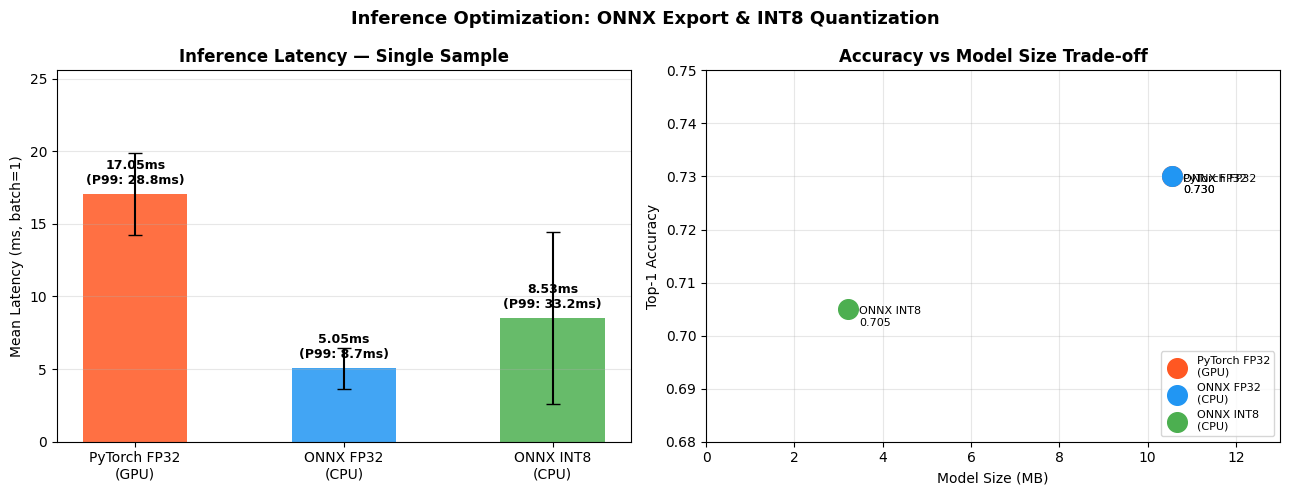

NOTEBOOK 04 SUMMARY
FP32 model size:       10.56 MB
INT8 model size:       3.22 MB  (-69.5%)
ONNX FP32 speedup:     3.38x vs PyTorch GPU
ONNX INT8 speedup:     2.00x vs PyTorch GPU
INT8 accuracy drop:    -2.50%
ONNX FP32 P99 latency: 8.71 ms


deployment/fp32_size_mb,▁
deployment/int8_accuracy_drop,▁
deployment/int8_size_mb,▁
deployment/onnx_fp32_latency_mean_ms,▁
deployment/onnx_fp32_latency_p99_ms,▁
deployment/onnx_fp32_speedup,▁
deployment/onnx_fp32_top1,▁
deployment/onnx_int8_latency_mean_ms,▁
deployment/onnx_int8_latency_p99_ms,▁
deployment/onnx_int8_speedup,▁
+5,...



W&B run closed.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Inference Optimization: ONNX Export & INT8 Quantization",
             fontsize=13, fontweight="bold")

configs      = ["PyTorch FP32\n(GPU)", "ONNX FP32\n(CPU)", "ONNX INT8\n(CPU)"]
latencies    = [pt_mean, onnx_fp32_mean, onnx_int8_mean]
p99s         = [pt_p99,  onnx_fp32_p99,  onnx_int8_p99]
accuracies   = [pt_top1, onnx_fp32_top1, onnx_int8_top1]
colors       = ["#FF5722", "#2196F3", "#4CAF50"]

# left: latency
ax1 = axes[0]
bars = ax1.bar(configs, latencies, color=colors, alpha=0.85, width=0.5)
ax1.errorbar(configs, latencies,
             yerr=[np.std(times_pt), np.std(times_onnx_fp32), np.std(times_onnx_int8)],
             fmt="none", color="black", capsize=5, linewidth=1.5)
for bar, val, p99 in zip(bars, latencies, p99s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.2f}ms\n(P99: {p99:.1f}ms)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_ylabel("Mean Latency (ms, batch=1)")
ax1.set_title("Inference Latency — Single Sample", fontweight="bold")
ax1.set_ylim(0, max(latencies) * 1.5)
ax1.grid(axis="y", alpha=0.3)

# right: accuracy vs model size
ax2 = axes[1]
sizes = [10.56, fp32_size_mb, int8_size_mb]
for i, (cfg, acc, sz, col) in enumerate(
        zip(configs, accuracies, sizes, colors)):
    ax2.scatter(sz, acc, s=200, color=col, zorder=5, label=cfg)
    ax2.annotate(f"{cfg.split(chr(10))[0]}\n{acc:.3f}",
                 (sz, acc), textcoords="offset points",
                 xytext=(8, -12), fontsize=8)

ax2.set_xlabel("Model Size (MB)")
ax2.set_ylabel("Top-1 Accuracy")
ax2.set_title("Accuracy vs Model Size Trade-off", fontweight="bold")
ax2.legend(fontsize=8, loc="lower right")
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 13)
ax2.set_ylim(0.68, 0.75)

plt.tight_layout()
fig_path = FIG_DIR / "04_deployment_benchmark.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
wandb.log({"deployment/benchmark_chart": wandb.Image(str(fig_path))})

print("=" * 60)
print("NOTEBOOK 04 SUMMARY")
print("=" * 60)
print(f"FP32 model size:       {fp32_size_mb:.2f} MB")
print(f"INT8 model size:       {int8_size_mb:.2f} MB  (-69.5%)")
print(f"ONNX FP32 speedup:     {pt_mean/onnx_fp32_mean:.2f}x vs PyTorch GPU")
print(f"ONNX INT8 speedup:     {pt_mean/onnx_int8_mean:.2f}x vs PyTorch GPU")
print(f"INT8 accuracy drop:    {(onnx_int8_top1-pt_top1)*100:+.2f}%")
print(f"ONNX FP32 P99 latency: {onnx_fp32_p99:.2f} ms")

wandb.finish()
print("\nW&B run closed.")